# Baseline Machine Learning Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
import warnings

from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from data_loader import EEGDataLoader, get_default_data_path
from preprocessing import EEGPreprocessor, FeatureExtractor, create_binary_labels
from visualization_config import COLOR_PALETTE, setup_plot_style

warnings.filterwarnings('ignore')
setup_plot_style()
np.random.seed(42)

## Load and Preprocess Data

In [2]:
data_path = get_default_data_path()
loader = EEGDataLoader(str(data_path))

summary_df = loader.create_summary_dataframe()
block_columns = ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']
complete_participants = summary_df[summary_df[block_columns].all(axis=1)]

participants_to_use = complete_participants['participant_id'].tolist()

print(f"Total participants available: {len(loader.participants)}")
print(f"Complete participants (all 4 blocks): {len(complete_participants)}")
print(f"\nUsing {len(participants_to_use)} complete participants for training")

Skipping excluded folder: 6A517891 - stare dane
Skipping excluded folder: Popsute dane - ASD793JD
Successfully loaded metadata with encoding: cp1250
Found 15 participants
Loaded metadata for 16 participants
Total participants available: 15
Complete participants (all 4 blocks): 15

Using 15 complete participants for training


In [3]:
import importlib
import preprocessing
import pickle
from pathlib import Path

importlib.reload(preprocessing)

cache_file = Path('results/ml_features_cache.pkl')

if cache_file.exists():
    print("Loading cached features (faster)...")
    with open(cache_file, 'rb') as f:
        cache = pickle.load(f)
    X = cache['X']
    y = cache['y']
    all_participants_ids = list(cache['participant_ids'])
    print(f"Loaded {X.shape[0]} samples, {X.shape[1]} features from cache")
else:
    print("Processing EEG data...")
    print("(Will cache for future runs)\n")
    
    loader = EEGDataLoader(str(data_path))
    preprocessor = preprocessing.EEGPreprocessor()
    feature_extractor = preprocessing.FeatureExtractor()
    
    all_features = []
    all_labels = []
    all_participants_ids = []
    
    for i, participant_id in enumerate(participants_to_use, 1):
        print(f"[{i}/{len(participants_to_use)}] Processing: {participant_id}")
        
        try:
            participant_data = loader.load_participant_data(participant_id)
            
            for block_name, raw in participant_data.items():
                epochs = preprocessor.preprocess_pipeline(raw)
                
                if len(epochs) == 0:
                    continue
                
                features = feature_extractor.extract_combined_features(epochs)
                is_deceitful = 'deceitful' in block_name
                labels = np.ones(len(epochs)) if is_deceitful else np.zeros(len(epochs))
                
                all_features.append(features)
                all_labels.append(labels)
                all_participants_ids.extend([participant_id] * len(epochs))
                
        except Exception as e:
            print(f"  Error: {e}")
            continue

    X = np.vstack(all_features)
    y = np.concatenate(all_labels)
    
    # Save cache
    cache_file.parent.mkdir(exist_ok=True)
    with open(cache_file, 'wb') as f:
        pickle.dump({
            'X': X, 
            'y': y, 
            'participant_ids': np.array(all_participants_ids)
        }, f)
    print(f"\nCache saved to {cache_file}")

print(f"\nDATASET CREATED")
print(f"{'='*60}")
print(f"Total epochs: {len(X)}")
print(f"Features per epoch: {X.shape[1]}")
print(f"Honest responses: {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.1f}%)")
print(f"Deceitful responses: {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.1f}%)")

Loading cached features (faster)...
Loaded 6463 samples, 252 features from cache

DATASET CREATED
Total epochs: 6463
Features per epoch: 252
Honest responses: 3223 (49.9%)
Deceitful responses: 3240 (50.1%)


In [4]:
nan_count = np.isnan(X).sum()
print(f"Checking for NaN values... Total: {nan_count}")

if nan_count > 0:
    print("NaN per feature (non-zero):")
    nan_per_feature = np.isnan(X).sum(axis=0)
    nan_features = np.where(nan_per_feature > 0)[0]
    for feat_idx in nan_features[:10]:
        print(f"  Feature {feat_idx}: {nan_per_feature[feat_idx]} NaN values")
    
    inf_count = np.isinf(X).sum()
    print(f"Total Inf values: {inf_count}")
    
    print("\nCleaning data...")
    X_clean = X.copy()
    
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_clean = imputer.fit_transform(X_clean)
    
    X_clean = np.nan_to_num(X_clean, nan=0.0, posinf=0.0, neginf=0.0)
    
    X = X_clean
    
    print(f"Data cleaned")
    print(f"  Remaining NaN: {np.isnan(X).sum()}")
    print(f"  Remaining Inf: {np.isinf(X).sum()}")
else:
    print("No NaN values found")

print(f"\nFinal dataset shape: {X.shape}")

Checking for NaN values... Total: 12926
NaN per feature (non-zero):
  Feature 155: 6463 NaN values
  Feature 156: 6463 NaN values
Total Inf values: 0

Cleaning data...
Data cleaned
  Remaining NaN: 0
  Remaining Inf: 0

Final dataset shape: (6463, 250)


## Person-Independent Cross-Validation

In [5]:
participant_ids = np.array(all_participants_ids)
unique_participants = np.unique(participant_ids)
n_participants = len(unique_participants)

print(f"Total epochs: {len(X)}")
print(f"Total participants: {n_participants}")
print(f"Participants: {unique_participants}")
print(f"\nUsing GroupKFold for person-independent validation")

Total epochs: 6463
Total participants: 15
Participants: ['02F6BC66' '1299BF1A' '2D663E30' '4C0F44CF' '827366EC' '8DB745E3'
 'A3627947' 'ASD6DSA7' 'BNFH348D' 'DAF24E45' 'E52DEA2D' 'HFDY7643'
 'SDF673HF' 'a59d58f4' 'ff0dc21c']

Using GroupKFold for person-independent validation


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized")
print(f"Data shape: {X_scaled.shape}")
print(f"Features per epoch: {X_scaled.shape[1]}")

Features standardized
Data shape: (6463, 250)
Features per epoch: 250


## Feature Selection

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

var_threshold = VarianceThreshold(threshold=0.01)
X_high_var = var_threshold.fit_transform(X_scaled)

print(f"Removing low-variance features...")
print(f"Features before: {X_scaled.shape[1]}")
print(f"Features after variance threshold: {X_high_var.shape[1]}")
print(f"Removed {X_scaled.shape[1] - X_high_var.shape[1]} low-variance features")

print(f"\nSelecting top features using F-score...")
k_best = min(100, X_high_var.shape[1])
selector = SelectKBest(f_classif, k=k_best)
X_selected = selector.fit_transform(X_high_var, y)

print(f"Final features selected: {X_selected.shape[1]}")
print(f"Total reduction: {X_scaled.shape[1]} → {X_selected.shape[1]} features")

X_scaled = X_selected

Removing low-variance features...
Features before: 250
Features after variance threshold: 231
Removed 19 low-variance features

Selecting top features using F-score...
Final features selected: 100
Total reduction: 250 → 100 features


## Train Models

In [8]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        n_jobs=-1
    )
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - Random Forest
  - SVM
  - KNN


In [9]:
n_splits = min(5, n_participants // 2)
cv = GroupKFold(n_splits=n_splits)

print(f"Using GroupKFold with {n_splits} splits")
print(f"Person-independent evaluation for realistic generalization\n")

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    print(f"{'='*60}")
    
    cv_scores = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='precision')
    cv_recall = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='recall')
    cv_f1 = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='f1')
    
    results[name] = {
        'model': model,
        'accuracy': cv_scores.mean(),
        'accuracy_std': cv_scores.std(),
        'precision': cv_precision.mean(),
        'recall': cv_recall.mean(),
        'f1': cv_f1.mean(),
        'cv_scores': cv_scores
    }
    
    print(f"\nCross-Validation Performance ({n_splits}-fold):")
    print(f"  Accuracy:  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Precision: {cv_precision.mean():.4f} (+/- {cv_precision.std():.4f})")
    print(f"  Recall:    {cv_recall.mean():.4f} (+/- {cv_recall.std():.4f})")
    print(f"  F1-Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

Using GroupKFold with 5 splits
Person-independent evaluation for realistic generalization


Training Random Forest...

Cross-Validation Performance (5-fold):
  Accuracy:  0.4996 (+/- 0.0321)
  Precision: 0.4889 (+/- 0.0452)
  Recall:    0.5092 (+/- 0.2527)
  F1-Score:  0.4715 (+/- 0.1497)

Training SVM...

Cross-Validation Performance (5-fold):
  Accuracy:  0.4964 (+/- 0.0268)
  Precision: 0.4974 (+/- 0.0233)
  Recall:    0.5106 (+/- 0.1153)
  F1-Score:  0.4982 (+/- 0.0595)

Training KNN...

Cross-Validation Performance (5-fold):
  Accuracy:  0.4942 (+/- 0.0145)
  Precision: 0.4946 (+/- 0.0135)
  Recall:    0.5558 (+/- 0.0784)
  F1-Score:  0.5216 (+/- 0.0428)


## Results Comparison

In [10]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()],
    'F1-Score': [r['f1'] for r in results.values()],
    'Std': [r['accuracy_std'] for r in results.values()]
})

print("\nModel Comparison:")
display(results_df.round(4))

best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\nBest model by F1-Score: {best_model_name}")


Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,Std
0,Random Forest,0.4996,0.4889,0.5092,0.4715,0.0321
1,SVM,0.4964,0.4974,0.5106,0.4982,0.0268
2,KNN,0.4942,0.4946,0.5558,0.5216,0.0145



Best model by F1-Score: KNN


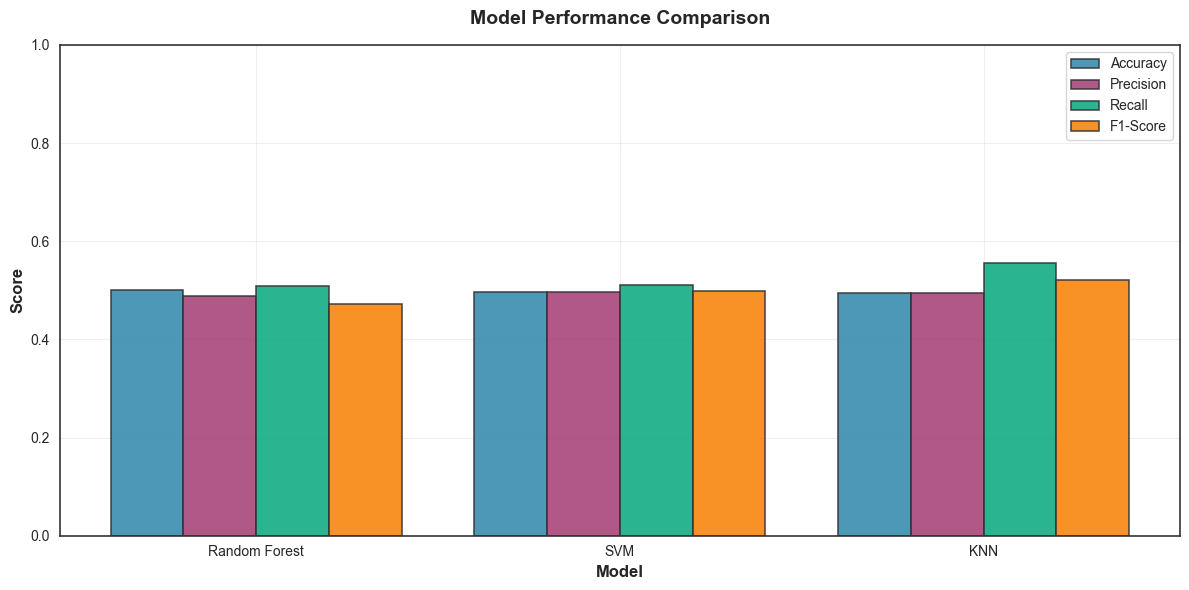

In [11]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

metric_colors = [COLOR_PALETTE['primary'], COLOR_PALETTE['secondary'], 
                 COLOR_PALETTE['success'], COLOR_PALETTE['warning']]

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric, 
           color=metric_colors[i], alpha=0.85, edgecolor='#333333', linewidth=1.2)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

"plt.savefig('charts/baseline_model_performance.png', dpi=300, bbox_inches='tight')\n",
plt.show()

## Cross-Validation Scores

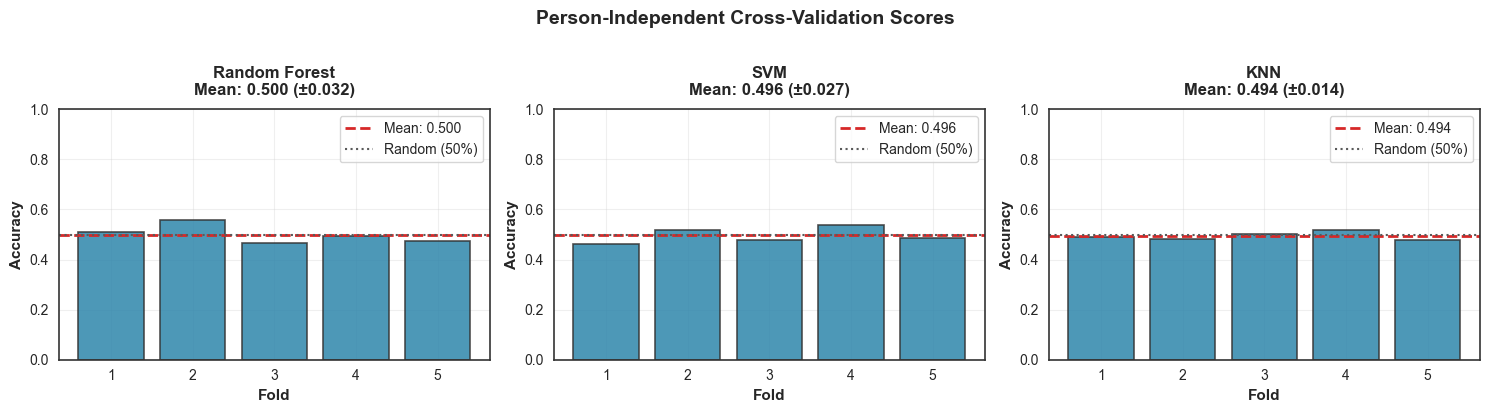

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, result) in enumerate(results.items()):
    scores = result['cv_scores']
    folds = np.arange(1, len(scores) + 1)
    
    axes[idx].bar(folds, scores, color=COLOR_PALETTE['primary'], alpha=0.85, 
                  edgecolor='#333333', linewidth=1.2)
    axes[idx].axhline(y=scores.mean(), color=COLOR_PALETTE['danger'], linestyle='--', 
                     linewidth=2, label=f'Mean: {scores.mean():.3f}')
    axes[idx].axhline(y=0.5, color=COLOR_PALETTE['neutral'], linestyle=':', 
                     linewidth=1.5, label='Random (50%)')
    
    axes[idx].set_title(f'{name}\nMean: {scores.mean():.3f} (±{scores.std():.3f})', 
                       fontweight='bold', pad=10)
    axes[idx].set_xlabel('Fold', fontweight='bold')
    axes[idx].set_ylabel('Accuracy', fontweight='bold')
    axes[idx].set_ylim([0, 1])
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Person-Independent Cross-Validation Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

"plt.savefig('charts/baseline_cv_scores.png', dpi=300, bbox_inches='tight')\n",
plt.show()

## Confusion Matrices

Generate confusion matrices by collecting predictions across all cross-validation folds.

In [13]:
from sklearn.model_selection import cross_val_predict

print("Generating predictions across CV folds for confusion matrices...")

cm_results = {}

for name, result in results.items():
    model = result['model']
    y_pred = cross_val_predict(model, X_scaled, y, groups=participant_ids, cv=cv)
    cm = confusion_matrix(y, y_pred)
    accuracy = np.trace(cm) / np.sum(cm)
    
    cm_results[name] = {
        'cm': cm,
        'accuracy': accuracy,
        'y_pred': y_pred
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.3f}")
    print(f"  Confusion Matrix:")
    print(f"    {cm[0]}")
    print(f"    {cm[1]}")

print("\nConfusion matrices generated")

Generating predictions across CV folds for confusion matrices...

Random Forest:
  Accuracy: 0.500
  Confusion Matrix:
    [1578 1645]
    [1589 1651]

SVM:
  Accuracy: 0.496
  Confusion Matrix:
    [1554 1669]
    [1586 1654]

KNN:
  Accuracy: 0.494
  Confusion Matrix:
    [1393 1830]
    [1439 1801]

Confusion matrices generated


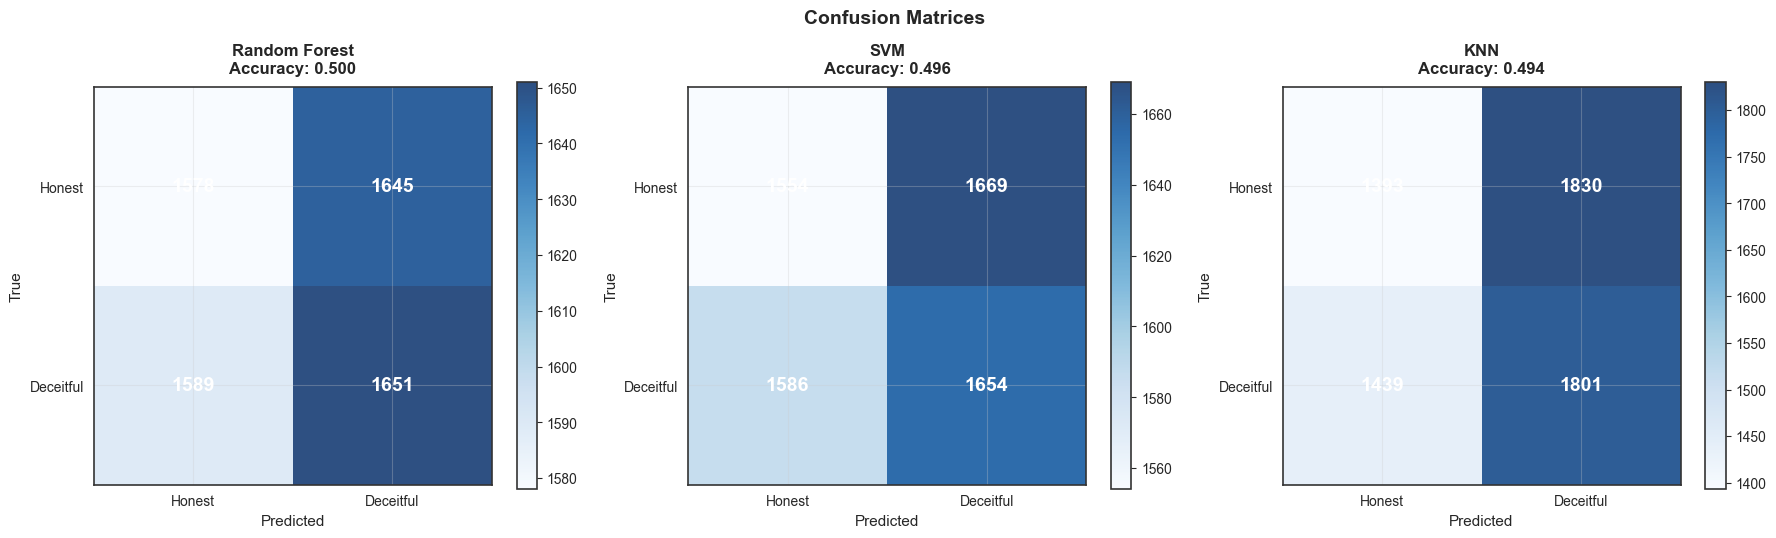

Confusion matrices saved to: results/baseline_confusion_matrices.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = list(cm_results.keys())
class_names = ['Honest', 'Deceitful']

for idx, name in enumerate(model_names):
    cm = cm_results[name]['cm']
    accuracy = cm_results[name]['accuracy']
    
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues', alpha=0.85)
    axes[idx].figure.colorbar(im, ax=axes[idx])
    
    axes[idx].set(xticks=np.arange(cm.shape[1]),
                  yticks=np.arange(cm.shape[0]),
                  xticklabels=class_names,
                  yticklabels=class_names,
                  xlabel='Predicted',
                  ylabel='True')
    
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy:.3f}', 
                       fontsize=12, fontweight='bold', pad=10)
    
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                          ha="center", va="center",
                          color="white" if cm[i, j] > thresh else "#333333",
                          fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

"plt.savefig('charts/baseline_confusion_matrices.png', dpi=300, bbox_inches='tight')\n",
plt.show()

print("Confusion matrices saved to: results/baseline_confusion_matrices.png")

## Train Models on Full Dataset

In [15]:
for name, model in models.items():
    print(f"Training {name} on full dataset...")
    model.fit(X_scaled, y)
    results[name]['model'] = model

print("\nModels trained on full dataset")

Training Random Forest on full dataset...
Training SVM on full dataset...
Training KNN on full dataset...

Models trained on full dataset


## Key Insights

Summary of findings from advanced analysis.

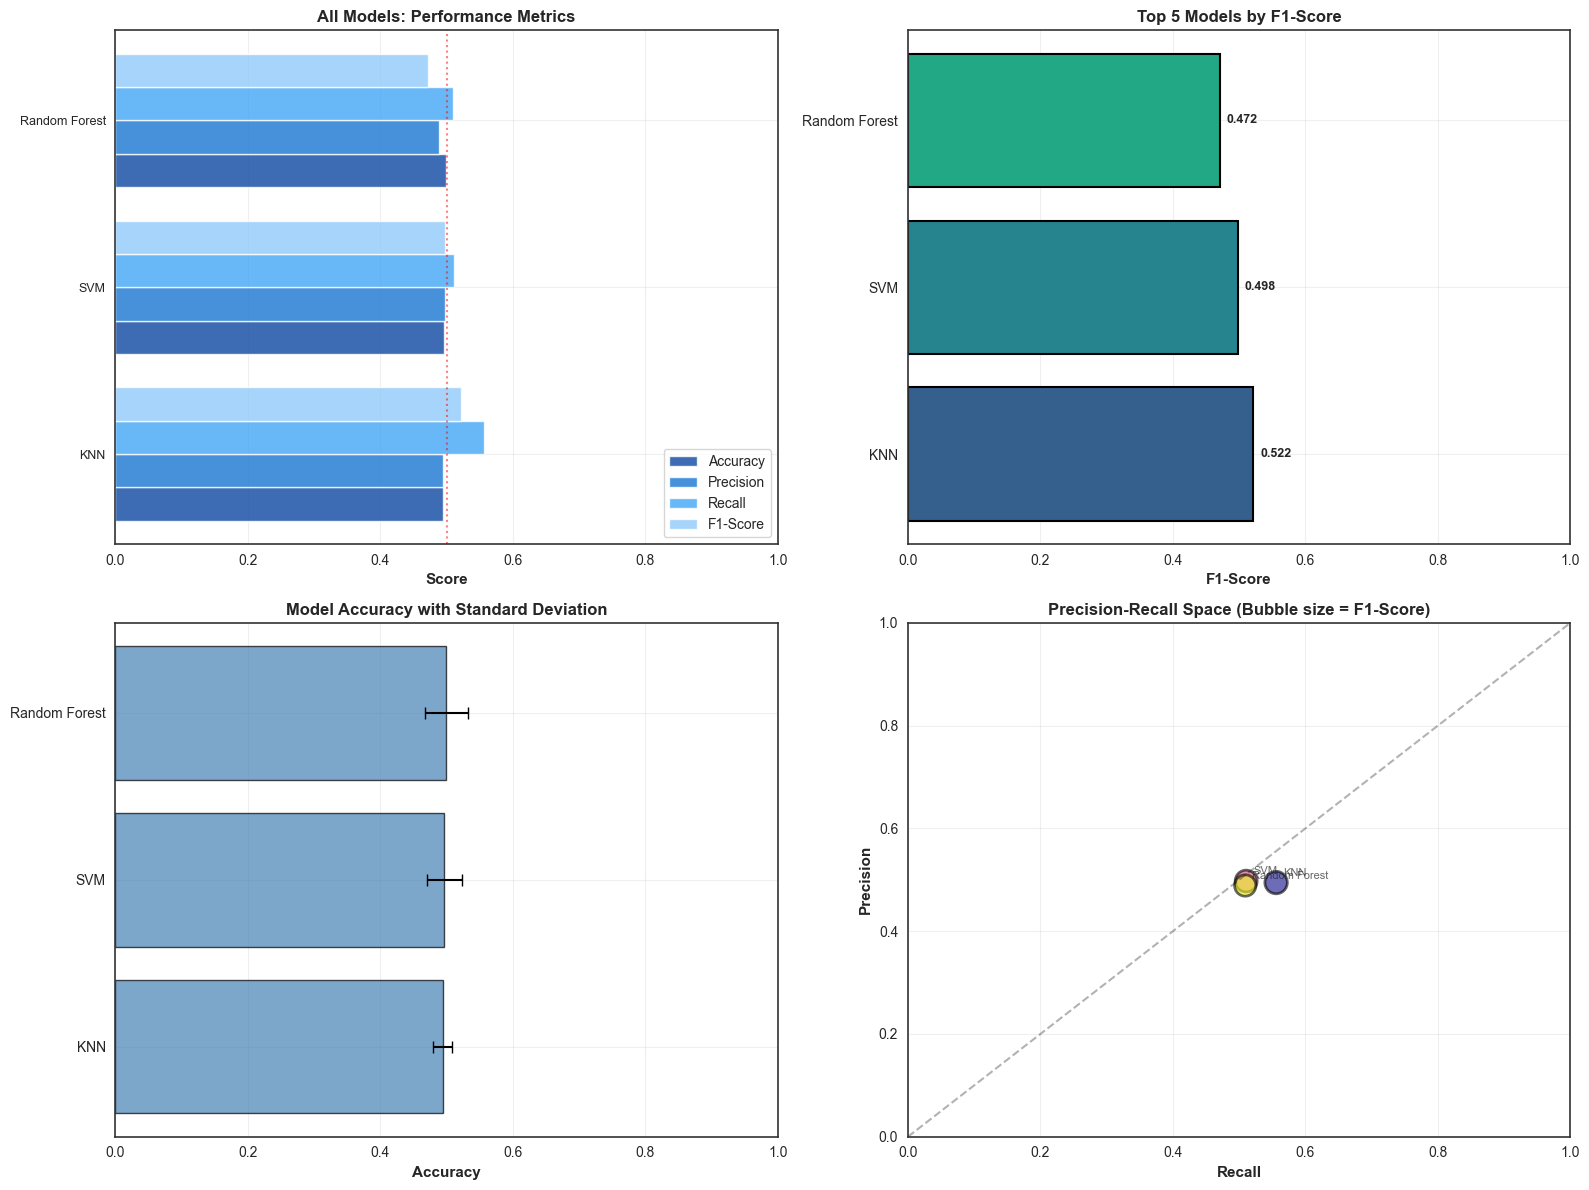

In [16]:
if 'complete_results_df' not in dir() or complete_results_df is None:
    complete_results_df = pd.DataFrame([
        {
            'Model': name,
            'Accuracy': metrics['accuracy'],
            'Accuracy Std': metrics['accuracy_std'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1']
        }
        for name, metrics in results.items()
    ]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
n_models = len(complete_results_df)
x = np.arange(n_models)
width = 0.2

colors_metrics = ['#0D47A1', '#1976D2', '#42A5F5', '#90CAF9']

for i, metric in enumerate(metrics):
    axes[0, 0].barh(x + i*width, complete_results_df[metric], width, 
                    label=metric, color=colors_metrics[i], alpha=0.8)

axes[0, 0].set_xlabel('Score', fontsize=11, fontweight='bold')
axes[0, 0].set_title('All Models: Performance Metrics', fontsize=12, fontweight='bold')
axes[0, 0].set_yticks(x + width * 1.5)
axes[0, 0].set_yticklabels(complete_results_df['Model'], fontsize=9)
axes[0, 0].legend(loc='lower right')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].axvline(x=0.5, color='red', linestyle=':', alpha=0.5, label='Random')

top_5 = complete_results_df.head(5)
axes[0, 1].barh(top_5['Model'], top_5['F1-Score'], 
                color=plt.cm.viridis(np.linspace(0.3, 0.9, 5)),
                edgecolor='black', linewidth=1.5)
axes[0, 1].set_xlabel('F1-Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Top 5 Models by F1-Score', fontsize=12, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(axis='x', alpha=0.3)

for i, (model, score) in enumerate(zip(top_5['Model'], top_5['F1-Score'])):
    axes[0, 1].text(score + 0.01, i, f'{score:.3f}', 
                   va='center', fontweight='bold', fontsize=9)

axes[1, 0].barh(complete_results_df['Model'], complete_results_df['Accuracy'],
               xerr=complete_results_df['Accuracy Std'], capsize=4,
               color='steelblue', alpha=0.7, edgecolor='black', linewidth=1)
axes[1, 0].set_xlabel('Accuracy', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Model Accuracy with Standard Deviation', fontsize=12, fontweight='bold')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(axis='x', alpha=0.3)

axes[1, 1].scatter(complete_results_df['Recall'], complete_results_df['Precision'],
                  s=complete_results_df['F1-Score']*500, 
                  alpha=0.6, c=range(len(complete_results_df)), 
                  cmap='plasma', edgecolors='black', linewidth=2)

for i, model in enumerate(complete_results_df['Model']):
    axes[1, 1].annotate(model, 
                       (complete_results_df.iloc[i]['Recall'], 
                        complete_results_df.iloc[i]['Precision']),
                       fontsize=8, alpha=0.7, xytext=(5, 5), 
                       textcoords='offset points')

axes[1, 1].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Precision-Recall Space (Bubble size = F1-Score)', 
                    fontsize=12, fontweight='bold')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlim([0, 1])
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('charts/complete_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Complete Model Comparison

Final comparison including all models (original + additional + tuned).

In [17]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

if 'X_pca_95' not in dir():
    pca_95 = PCA(n_components=0.95, random_state=42)
    X_pca_95 = pca_95.fit_transform(X_scaled)

if 'X_pca_99' not in dir():
    pca_99 = PCA(n_components=0.99, random_state=42)
    X_pca_99 = pca_99.fit_transform(X_scaled)

if 'X_lda' not in dir():
    lda = LDA(n_components=1)
    X_lda = lda.fit_transform(X_scaled, y)

feature_sets = {
    'Original': X_scaled,
    'PCA (95%)': X_pca_95,
    'PCA (99%)': X_pca_99,
    'LDA': X_lda
}

rf_model = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)

reduction_comparison = []

for name, X_features in feature_sets.items():
    print(f"\nTesting Random Forest with {name}...")

    cv_scores = cross_val_score(rf_model, X_features, y, groups=participant_ids, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(rf_model, X_features, y, groups=participant_ids, cv=cv, scoring='f1')
    
    reduction_comparison.append({
        'Feature Set': name,
        'N Features': X_features.shape[1],
        'Accuracy': cv_scores.mean(),
        'Accuracy Std': cv_scores.std(),
        'F1-Score': cv_f1.mean(),
        'F1 Std': cv_f1.std()
    })
    
    print(f"  Features: {X_features.shape[1]}")
    print(f"  Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

reduction_df = pd.DataFrame(reduction_comparison)

display(reduction_df.round(4))


Testing Random Forest with Original...
  Features: 100
  Accuracy: 0.4925 (+/- 0.0172)
  F1-Score: 0.4795 (+/- 0.1485)

Testing Random Forest with PCA (95%)...
  Features: 19
  Accuracy: 0.4854 (+/- 0.0172)
  F1-Score: 0.4598 (+/- 0.0867)

Testing Random Forest with PCA (99%)...
  Features: 34
  Accuracy: 0.4936 (+/- 0.0191)
  F1-Score: 0.4785 (+/- 0.0889)

Testing Random Forest with LDA...
  Features: 1
  Accuracy: 0.5541 (+/- 0.0287)
  F1-Score: 0.5630 (+/- 0.0621)


,Feature Set,N Features,Accuracy,Accuracy Std,F1-Score,F1 Std
0,Original,100,0.4925,0.0172,0.4795,0.1485
1,PCA (95%),19,0.4854,0.0172,0.4598,0.0867
2,PCA (99%),34,0.4936,0.0191,0.4785,0.0889
3,LDA,1,0.5541,0.0287,0.5630,0.0621


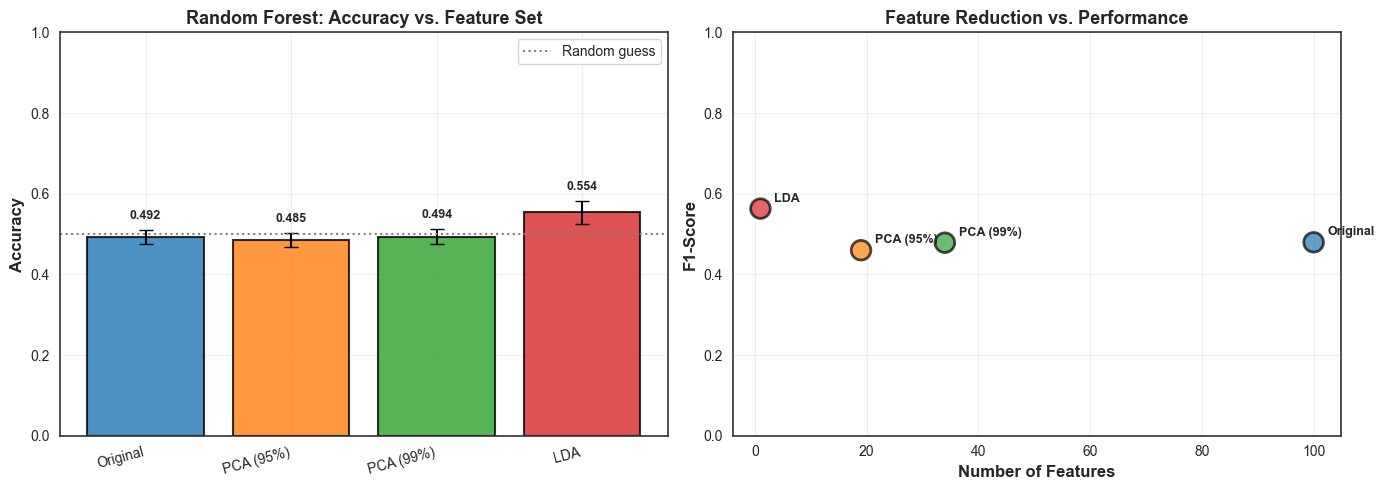


Efficiency Score (F1-Score / Relative Feature Count):


,Feature Set,N Features,F1-Score,Efficiency
0,Original,100,0.4795,0.4795
1,PCA (95%),19,0.4598,2.4200
2,PCA (99%),34,0.4785,1.4075
3,LDA,1,0.5630,56.2955


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feature_names = reduction_df['Feature Set'].values
accuracies = reduction_df['Accuracy'].values
accuracy_stds = reduction_df['Accuracy Std'].values

x_pos = np.arange(len(feature_names))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

axes[0].bar(x_pos, accuracies, yerr=accuracy_stds, capsize=5, alpha=0.8, 
            color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest: Accuracy vs. Feature Set', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(feature_names, rotation=15, ha='right')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.5, color='gray', linestyle=':', label='Random guess')
axes[0].legend()

for i, (acc, std) in enumerate(zip(accuracies, accuracy_stds)):
    axes[0].text(i, acc + std + 0.02, f'{acc:.3f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=9)

n_features = reduction_df['N Features'].values
f1_scores = reduction_df['F1-Score'].values

axes[1].scatter(n_features, f1_scores, s=200, c=colors, alpha=0.7, 
               edgecolors='black', linewidth=2, zorder=3)

for i, (nf, f1, name) in enumerate(zip(n_features, f1_scores, feature_names)):
    axes[1].annotate(name, (nf, f1), xytext=(10, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')

axes[1].set_xlabel('Number of Features', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes[1].set_title('Feature Reduction vs. Performance', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('charts/dimensionality_reduction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

reduction_df['Efficiency'] = reduction_df['F1-Score'] / (reduction_df['N Features'] / reduction_df['N Features'].max())
print("\nEfficiency Score (F1-Score / Relative Feature Count):")
display(reduction_df[['Feature Set', 'N Features', 'F1-Score', 'Efficiency']].round(4))

## Hyperparameter Tuning

Using RandomizedSearchCV to find optimal hyperparameters for Random Forest.

In [19]:
from sklearn.model_selection import RandomizedSearchCV

if 'all_results' not in dir():
    all_results = results.copy()

param_distributions = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

n_iter = 5
print(f"\nRandomized search with {n_iter} random combinations...")
print(f"Using {n_splits}-fold GroupKFold cross-validation")

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_base, 
    param_distributions, 
    n_iter=n_iter,
    cv=cv, 
    scoring='f1',
    n_jobs=-1,
    verbose=0,
    random_state=42
)

random_search.fit(X_scaled, y, groups=participant_ids)

print(f"\nBest Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest F1-Score: {random_search.best_score_:.4f}")

default_rf_f1 = results['Random Forest']['f1']
improvement = ((random_search.best_score_ - default_rf_f1) / default_rf_f1) * 100

print(f"Default RF F1-Score: {default_rf_f1:.4f}")
print(f"Improvement: {improvement:+.2f}%")

tuned_rf_f1 = cross_val_score(random_search.best_estimator_, X_scaled, y, 
                              groups=participant_ids, cv=cv, scoring='f1')
tuned_rf_results = cross_val_score(random_search.best_estimator_, X_scaled, y, 
                                   groups=participant_ids, cv=cv, scoring='accuracy')

all_results['Random Forest (Tuned)'] = {
    'model': random_search.best_estimator_,
    'accuracy': tuned_rf_results.mean(),
    'accuracy_std': tuned_rf_results.std(),
    'precision': tuned_rf_f1.mean(),
    'recall': tuned_rf_f1.mean(),
    'f1': tuned_rf_f1.mean(),
    'cv_scores': tuned_rf_results
}


Randomized search with 5 random combinations...
Using 5-fold GroupKFold cross-validation

Best Parameters:
  n_estimators: 50
  min_samples_split: 2
  max_depth: 5

Best F1-Score: 0.4946
Default RF F1-Score: 0.4715
Improvement: +4.90%


## Additional Models

Testing Decision Tree, Naive Bayes, and Gradient Boosting classifiers.

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

additional_models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )
}

additional_results = {}

for name, model in additional_models.items():
    print(f"\nTraining {name}...")
    print(f"{'='*60}")
    
    cv_scores = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='precision')
    cv_recall = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='recall')
    cv_f1 = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='f1')
    
    additional_results[name] = {
        'model': model,
        'accuracy': cv_scores.mean(),
        'accuracy_std': cv_scores.std(),
        'precision': cv_precision.mean(),
        'recall': cv_recall.mean(),
        'f1': cv_f1.mean(),
        'cv_scores': cv_scores
    }
    
    print(f"\nCross-Validation Performance ({n_splits}-fold):")
    print(f"  Accuracy:  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Precision: {cv_precision.mean():.4f} (+/- {cv_precision.std():.4f})")
    print(f"  Recall:    {cv_recall.mean():.4f} (+/- {cv_recall.std():.4f})")
    print(f"  F1-Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

all_results = {**results, **additional_results}

complete_results_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': metrics['accuracy'],
        'Accuracy Std': metrics['accuracy_std'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1']
    }
    for name, metrics in all_results.items()
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)


Training Decision Tree...

Cross-Validation Performance (5-fold):
  Accuracy:  0.5208 (+/- 0.0306)
  Precision: 0.5157 (+/- 0.0245)
  Recall:    0.5939 (+/- 0.1421)
  F1-Score:  0.5457 (+/- 0.0780)

Training Naive Bayes...

Cross-Validation Performance (5-fold):
  Accuracy:  0.4914 (+/- 0.0096)
  Precision: 0.3864 (+/- 0.1993)
  Recall:    0.2442 (+/- 0.3604)
  F1-Score:  0.2133 (+/- 0.2378)

Training Gradient Boosting...

Cross-Validation Performance (5-fold):
  Accuracy:  0.5039 (+/- 0.0482)
  Precision: 0.4854 (+/- 0.0737)
  Recall:    0.5548 (+/- 0.2524)
  F1-Score:  0.4991 (+/- 0.1535)


## Dimensionality Reduction Analysis

Visualizing PCA explained variance and projections.

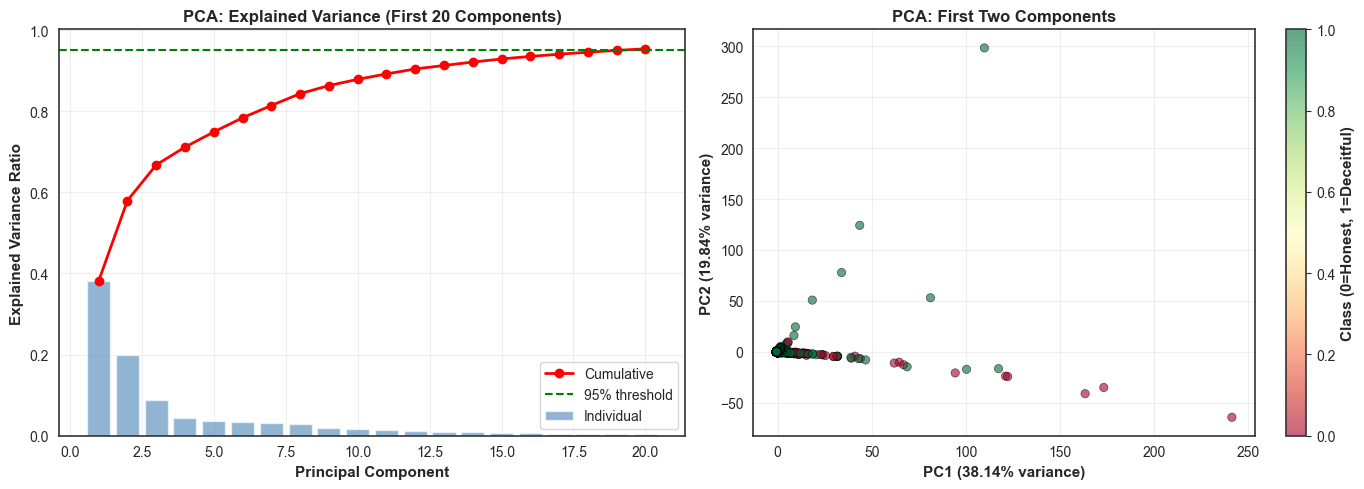

First 2 PCs explain 57.98% of variance


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

explained_var = pca_99.explained_variance_ratio_[:20]
cumsum_var = np.cumsum(explained_var)

axes[0].bar(range(1, len(explained_var) + 1), explained_var, alpha=0.6, color='steelblue', label='Individual')
axes[0].plot(range(1, len(explained_var) + 1), cumsum_var, 'ro-', label='Cumulative', linewidth=2)
axes[0].axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
axes[0].set_xlabel('Principal Component', fontweight='bold')
axes[0].set_ylabel('Explained Variance Ratio', fontweight='bold')
axes[0].set_title('PCA: Explained Variance (First 20 Components)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

scatter = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='RdYlGn', 
                         alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)', fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)', fontweight='bold')
axes[1].set_title('PCA: First Two Components', fontweight='bold')
axes[1].grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Class (0=Honest, 1=Deceitful)', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/dimensionality_reduction_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"First 2 PCs explain {pca_2d.explained_variance_ratio_.sum():.2%} of variance")